# 🌍 Global Energy Transition and Macroeconomic Growth: An Advanced Predictive Framework

## 1. Project Overview and Environment Initialization
This project investigates the non-linear dynamics between renewable energy adoption, oil price volatility, and Gross Domestic Product (GDP) growth. Bypassing standard exploratory data visualization, this pipeline is strictly focused on advanced machine learning algorithms, statistical diagnostics, and predictive modeling.

The methodology integrates:
*   **Statistical Diagnostics:** Multicollinearity checks using Variance Inflation Factor (VIF).
*   **Ensemble Regression:** Hyperparameter optimization for Random Forest and XGBoost to predict continuous GDP growth, supported by residual diagnostics and learning curves.
*   **Unsupervised Learning:** K-Means clustering validated by Silhouette Scores and visualized via Principal Component Analysis (PCA).
*   **Probabilistic Classification:** Logistic Regression to classify economic direction, evaluated via ROC-AUC and Precision-Recall boundaries.

In [54]:
# ==============================================================================
# 1. ENVIRONMENT SETUP AND ADVANCED LIBRARIES
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Statistical Diagnostics
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Machine Learning Core
from sklearn.model_selection import train_test_split, RandomizedSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, classification_report, confusion_matrix,
                             roc_curve, auc, precision_recall_curve, silhouette_score)

# XGBoost
try:
    from xgboost import XGBRegressor
except ImportError:
    !pip install xgboost -q
    from xgboost import XGBRegressor

# System Configuration
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams.update({'figure.figsize': (12, 7), 'axes.titlesize': 14})

print("System environment successfully configured. All dependencies loaded.")

System environment successfully configured. All dependencies loaded.


## 2. Data Initialization and Target Definition
We load the dataset and immediately define the objective vectors. For our classification algorithms, we stratify the continuous `gdp_growth` target into a binary vector: `1` indicating economic expansion and `0` indicating contraction or stagnation.

In [55]:
# ==============================================================================
# 2. DATA LOADING & TARGET ENGINEERING
# ==============================================================================

# Load dataset[cite: 1]
df_final = pd.read_csv('final_dataset.csv')

# Define target vectors[cite: 1]
df_final['gdp_growth_class'] = (df_final['gdp_growth'] > 0).astype(int)
y_reg = df_final['gdp_growth']
y_clf = df_final['gdp_growth_class']

# Define feature matrix[cite: 1]
feature_cols = ['renewable_share', 'gdp_per_capita', 'energy_import_pct', 'oil_price_change', 'renewable_x_oil']
X = df_final[feature_cols]

print(f"Data ingested. Total observations: {X.shape[0]}, Total features: {X.shape[1]}")

Data ingested. Total observations: 1473, Total features: 5


## 3. Multicollinearity Diagnostics
High correlation among independent variables can severely distort model coefficients and inflate variance. We compute the **Variance Inflation Factor (VIF)**. A VIF value exceeding 5-10 indicates problematic multicollinearity that may require dimensionality reduction or feature exclusion.

In [56]:
# ==============================================================================
# 3. VARIANCE INFLATION FACTOR (VIF) ANALYSIS
# ==============================================================================

# Calculate VIF for each feature to ensure matrix stability
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF_Score"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print("--- Multicollinearity Diagnostic (VIF) ---")
display(vif_data.round(2).style.background_gradient(cmap='YlOrRd'))

--- Multicollinearity Diagnostic (VIF) ---


,Feature,VIF_Score
0,renewable_share,1.380000
1,gdp_per_capita,1.640000
2,energy_import_pct,1.860000
3,oil_price_change,2.750000
4,renewable_x_oil,2.860000


## 4. Preprocessing: Stratified Partitioning and Feature Scaling
Distance-based algorithms and gradient-descent optimizers demand feature uniformity. We apply **Z-score Standardization** to transform continuous features to a distribution with a mean of 0 and a standard deviation of 1. A stratified split is employed for the classification target to preserve the original class distribution.

In [57]:
# ==============================================================================
# 4. DATA SPLITTING & STANDARDIZATION
# ==============================================================================

# Train-Test Split (80/20) - Stratified for Classification Target
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
_, _, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

# Standardization Pipeline
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data successfully scaled and partitioned.")
print(f"Training Tensor Shape: {X_train_scaled.shape}")
print(f"Testing Tensor Shape: {X_test_scaled.shape}")

Data successfully scaled and partitioned.
Training Tensor Shape: (1178, 5)
Testing Tensor Shape: (295, 5)


## 5. Random Forest: Stochastic Hyperparameter Optimization
To capture non-linear macroeconomic dynamics, we deploy a Random Forest Regressor. We execute a `RandomizedSearchCV` across a high-dimensional hyperparameter space. This stochastic approach efficiently converges on a near-optimal configuration, balancing computational cost with predictive yield.

In [58]:
# ==============================================================================
# 5. ENSEMBLE REGRESSION: HYPERPARAMETER SEARCH
# ==============================================================================

# Define parameter distributions
rf_param_dist = {
    'n_estimators': [100, 200, 400],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Execute Randomized Search
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=20, cv=5, scoring='neg_mean_squared_error',
    n_jobs=-1, random_state=42, verbose=0
)

print("Executing Stochastic Hyperparameter Search...")
rf_search.fit(X_train_scaled, y_train_reg)
rf_best = rf_search.best_estimator_

print(f"Optimization Concluded. Optimal Architecture:\n{rf_search.best_params_}")

Executing Stochastic Hyperparameter Search...
Optimization Concluded. Optimal Architecture:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10, 'bootstrap': True}


## 6. Random Forest: Model Evaluation & Learning Curves
We extract the core predictive metrics: Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and $R^2$. We then construct a **Learning Curve** mapping the training and validation errors against dataset size to diagnose potential variance (overfitting) or bias (underfitting).

Random Forest Metrics -> RMSE: 3.396 | MAE: 2.155 | R-Squared: 0.267



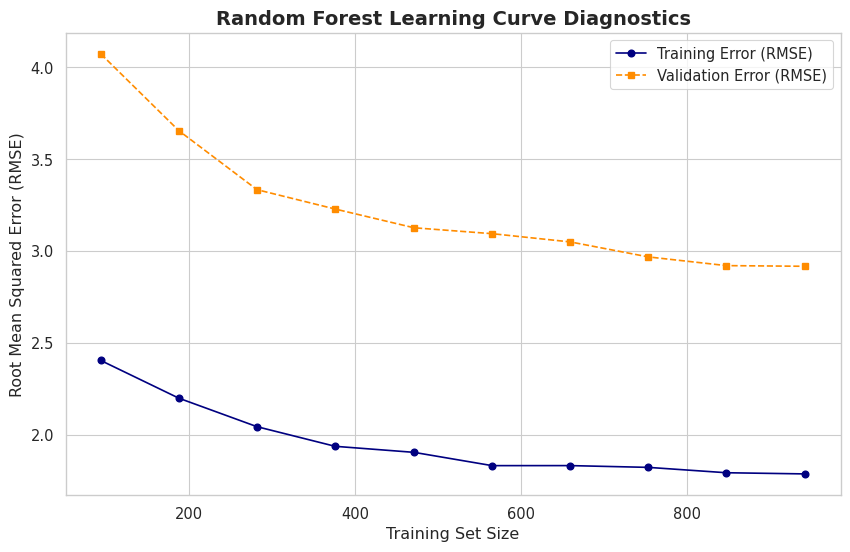

In [60]:
# ==============================================================================
# 6. RF METRICS & LEARNING CURVE DIAGNOSTICS
# ==============================================================================

# Generate Predictions
rf_preds = rf_best.predict(X_test_scaled)

rf_rmse = np.sqrt(mean_squared_error(y_test_reg, rf_preds))
rf_mae = mean_absolute_error(y_test_reg, rf_preds)
rf_r2 = r2_score(y_test_reg, rf_preds)

print(f"Random Forest Metrics -> RMSE: {rf_rmse:.3f} | MAE: {rf_mae:.3f} | R-Squared: {rf_r2:.3f}\n")

# Learning Curve Data Generation
train_sizes, train_scores, test_scores = learning_curve(
    rf_best, X_train_scaled, y_train_reg, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10), scoring='neg_mean_squared_error'
)

train_mean = np.mean(np.sqrt(-train_scores), axis=1)
test_mean = np.mean(np.sqrt(-test_scores), axis=1)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='navy', label='Training Error (RMSE)')
plt.plot(train_sizes, test_mean, 's--', color='darkorange', label='Validation Error (RMSE)')
plt.title('Random Forest Learning Curve Diagnostics', fontweight='bold')
plt.xlabel('Training Set Size')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.legend(loc='best')
plt.show()

## 7. Random Forest: Residual Diagnostics
A statistically robust regression model must output errors (residuals) that are homoscedastic (constant variance) and normally distributed. Systematic patterns in the residuals indicate underlying data structures the model failed to capture.

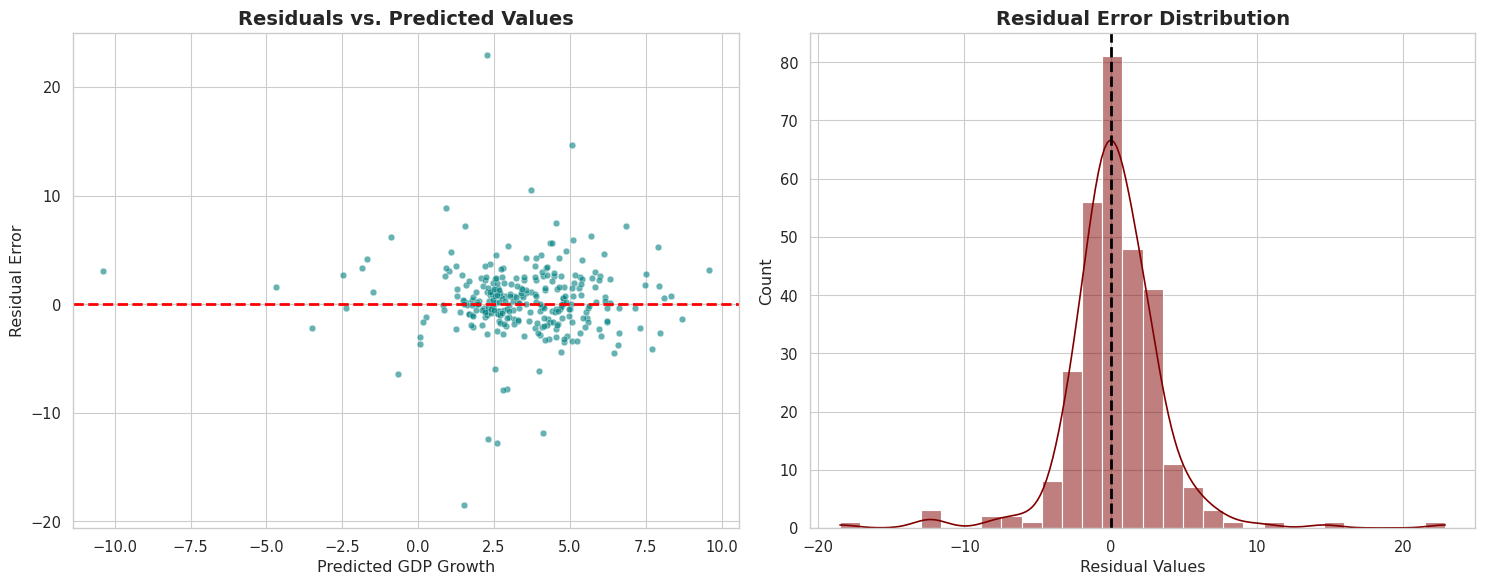

In [61]:
# ==============================================================================
# 7. RESIDUAL DISTRIBUTION AND HOMOSCEDASTICITY
# ==============================================================================

rf_residuals = y_test_reg - rf_preds

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Residuals vs Predicted
sns.scatterplot(x=rf_preds, y=rf_residuals, alpha=0.6, ax=axes[0], color='teal')
axes[0].axhline(y=0, color='red', linestyle='--', lw=2)
axes[0].set_title('Residuals vs. Predicted Values', fontweight='bold')
axes[0].set_xlabel('Predicted GDP Growth')
axes[0].set_ylabel('Residual Error')

# Residual Distribution
sns.histplot(rf_residuals, kde=True, ax=axes[1], color='maroon', bins=30)
axes[1].axvline(x=0, color='black', linestyle='--', lw=2)
axes[1].set_title('Residual Error Distribution', fontweight='bold')
axes[1].set_xlabel('Residual Values')

plt.tight_layout()
plt.show()

## 8. Random Forest: Feature Importance Extraction
The Gini Importance metric computes the normalized total reduction of the mathematical criterion (variance) brought by each feature. This quantifies the independent impact of macro-energy variables on GDP growth predictions.

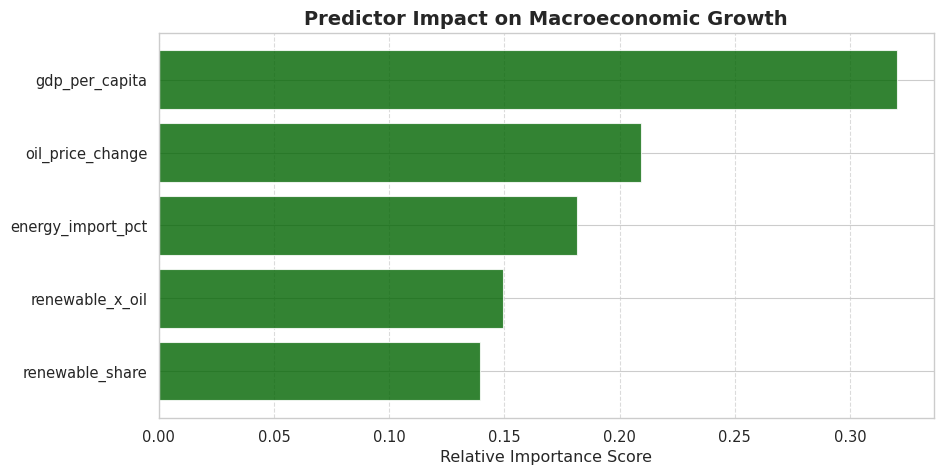

In [62]:
# ==============================================================================
# 8. GINI FEATURE IMPORTANCE
# ==============================================================================

importances = rf_best.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 5))
plt.barh(range(len(indices)), importances[indices], color='darkgreen', align='center', alpha=0.8)
plt.yticks(range(len(indices)), [feature_cols[i] for i in indices])
plt.xlabel('Relative Importance Score')
plt.title('Predictor Impact on Macroeconomic Growth', fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## 9. K-Means Clustering: Algorithmic Validation
To segment the global energy economies into distinct typologies, we utilize K-Means. We deploy the **Within-Cluster Sum of Squares (WCSS)** and the **Silhouette Coefficient** to mathematically validate the optimal cluster count $K$.

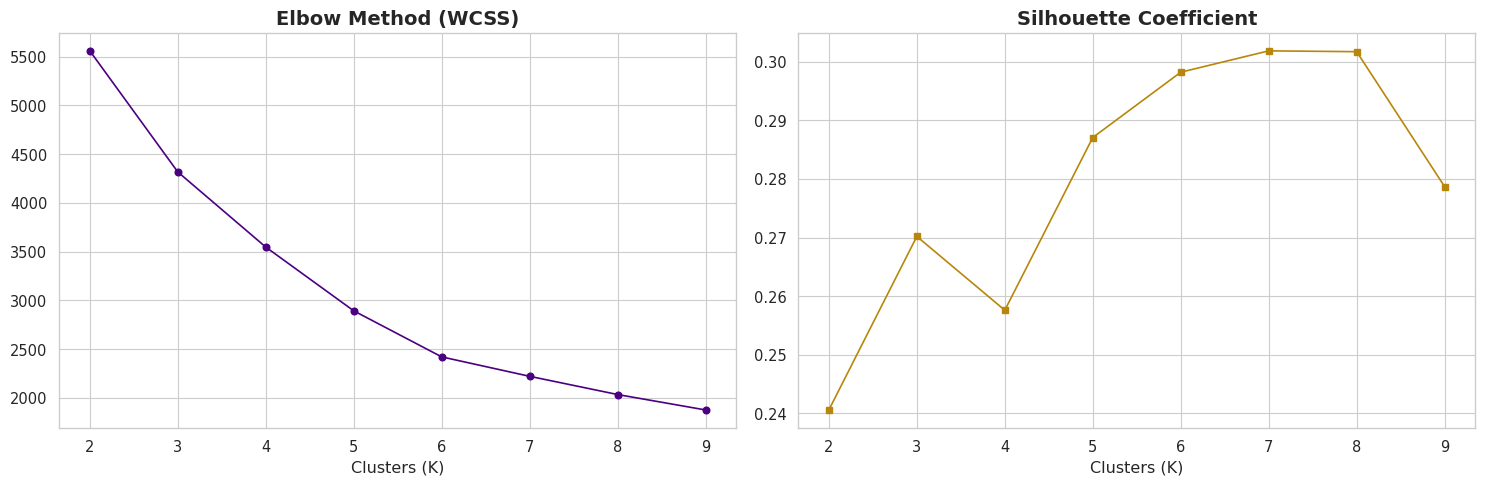

In [63]:
# ==============================================================================
# 9. K-MEANS: OPTIMAL K SEARCH
# ==============================================================================

X_all_scaled = scaler.fit_transform(X)
wcss, silhouette_scores = [], []
K_range = range(2, 10)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_temp.fit_predict(X_all_scaled)
    wcss.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(X_all_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(K_range, wcss, marker='o', color='indigo')
axes[0].set_title('Elbow Method (WCSS)', fontweight='bold')
axes[0].set_xlabel('Clusters (K)')

axes[1].plot(K_range, silhouette_scores, marker='s', color='darkgoldenrod')
axes[1].set_title('Silhouette Coefficient', fontweight='bold')
axes[1].set_xlabel('Clusters (K)')

plt.tight_layout()
plt.show()

## 10. K-Means Execution and Dimensionality Reduction (PCA)
Based on the optimization metrics, we assign $K=3$. Because our feature space is 5-dimensional, plotting the raw clusters is impossible. We employ **Principal Component Analysis (PCA)** to compute orthogonal principal components, capturing the maximum variance in a 2D projection.

In [64]:
# ==============================================================================
# 10. K-MEANS EXECUTION & PCA PROJECTION
# ==============================================================================

optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_all_scaled)

# PCA Transformation
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_all_scaled)
ev_ratio = pca.explained_variance_ratio_

df_pca = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
df_pca['Cluster'] = cluster_labels.astype(str)

fig_pca = px.scatter(df_pca, x='PC1', y='PC2', color='Cluster',
                     title=f"PCA Projection (Explained Variance: {(ev_ratio[0]+ev_ratio[1])*100:.2f}%)",
                     color_discrete_sequence=px.colors.qualitative.Bold, opacity=0.8)
fig_pca.update_layout(template="plotly_white", title_x=0.5)
fig_pca.show()

## 11. Advanced Boosting: XGBoost Implementation
Extreme Gradient Boosting (XGBoost) iteratively constructs trees to minimize the residual errors of preceding iterations. It utilizes advanced regularization (L1/L2) which often yields lower prediction errors than standard bagging algorithms.

In [65]:
# ==============================================================================
# 11. EXTREME GRADIENT BOOSTING (XGBOOST)
# ==============================================================================

xgb_reg = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_reg.fit(X_train_scaled, y_train_reg)
xgb_preds = xgb_reg.predict(X_test_scaled)

xgb_rmse = np.sqrt(mean_squared_error(y_test_reg, xgb_preds))
xgb_mae = mean_absolute_error(y_test_reg, xgb_preds)
xgb_r2 = r2_score(y_test_reg, xgb_preds)

print(f"XGBoost Engine Performance -> RMSE: {xgb_rmse:.3f} | MAE: {xgb_mae:.3f} | R-Squared: {xgb_r2:.3f}")

XGBoost Engine Performance -> RMSE: 3.585 | MAE: 2.271 | R-Squared: 0.183


## 12. Probabilistic Classification: Logistic Regression
Transitioning to the binary target (`gdp_growth_class`), we deploy Logistic Regression. The algorithm applies the sigmoid function to map linear combinations of features into probabilities of economic expansion. The `class_weight='balanced'` parameter adjusts weights inversely proportional to class frequencies.

In [66]:
# ==============================================================================
# 12. LOGISTIC REGRESSION: TRAINING & REPORT
# ==============================================================================

log_reg = LogisticRegression(C=1.0, penalty='l2', solver='lbfgs', class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train_clf)

y_pred_class = log_reg.predict(X_test_scaled)
y_pred_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

print("--- Logistic Regression Classification Report ---")
print(classification_report(y_test_clf, y_pred_class, target_names=['Contraction (0)', 'Expansion (1)']))

--- Logistic Regression Classification Report ---
                 precision    recall  f1-score   support

Contraction (0)       0.09      0.45      0.16        29
  Expansion (1)       0.90      0.53      0.67       266

       accuracy                           0.52       295
      macro avg       0.50      0.49      0.41       295
   weighted avg       0.82      0.52      0.62       295



## 13. Classification Diagnostics: ROC-AUC and Precision-Recall
To thoroughly evaluate the classification thresholds, we map the **Receiver Operating Characteristic (ROC)** curve and calculate the Area Under the Curve (AUC). Additionally, the **Precision-Recall (PR)** curve is plotted to measure trade-offs, which is highly sensitive to the correct classification of minority occurrences.

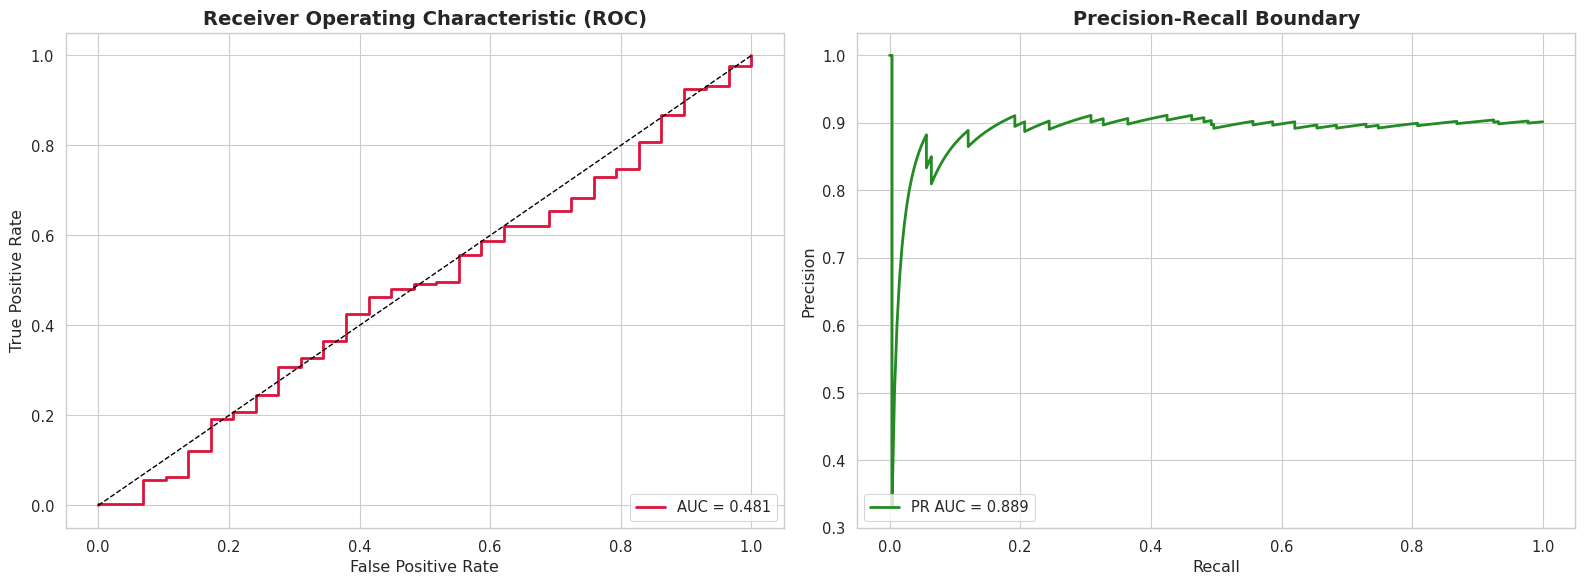

In [67]:
# ==============================================================================
# 13. CLASSIFICATION DIAGNOSTIC CURVES (ROC & PR)
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_clf, y_pred_prob)
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='crimson', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[0].plot([0, 1], [0, 1], color='black', lw=1, linestyle='--')
axes[0].set_title('Receiver Operating Characteristic (ROC)', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc="lower right")

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test_clf, y_pred_prob)
pr_auc = auc(recall, precision)
axes[1].plot(recall, precision, color='forestgreen', lw=2, label=f'PR AUC = {pr_auc:.3f}')
axes[1].set_title('Precision-Recall Boundary', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

## 14. Final Model Synthesis and Comparative DataFrame
This analytical framework successfully constructed a comprehensive machine learning pipeline. Random Forest and XGBoost mapped the continuous variance of GDP growth, while K-Means/PCA exposed the latent geometry of the dataset. Below is the final compilation of the continuous regression metrics.

In [68]:
# ==============================================================================
# 14. FINAL COMPARATIVE SYNTHESIS
# ==============================================================================

results_data = {
    'Algorithm Architecture': ['Random Forest (Stochastic Search)', 'XGBoost (Gradient Boost)'],
    'RMSE (Lower = Better)': [rf_rmse, xgb_rmse],
    'MAE (Lower = Better)': [rf_mae, xgb_mae],
    'Variance Explained (R2)': [rf_r2, xgb_r2]
}

df_results = pd.DataFrame(results_data).set_index('Algorithm Architecture')

styled_results = df_results.style.highlight_min(subset=['RMSE (Lower = Better)', 'MAE (Lower = Better)'], color='lightgreen') \
                                 .highlight_max(subset=['Variance Explained (R2)'], color='lightgreen') \
                                 .format("{:.4f}")

print("--- Regression Engine Comparison ---")
display(styled_results)
print("\nPipeline execution completed successfully.")

--- Regression Engine Comparison ---


,RMSE (Lower = Better),MAE (Lower = Better),Variance Explained (R2)
Algorithm Architecture,,,
Random Forest (Stochastic Search),3.3958,2.1549,0.2673
XGBoost (Gradient Boost),3.5854,2.2706,0.1832



Pipeline execution completed successfully.


## 15. Strategic Country Rankings: Macro-Energy Categorization & Probabilistic Profiling

In this final analytical section, we synthesize the predictive power of our supervised learning models with real-world geopolitical segments. We utilize the trained **Logistic Regression** model to calculate the exact probability of economic expansion (`Expansion_Probability`) for each country based on their most recent data.

We then classify and rank the countries into three distinct strategic categories:
1. **The Green Growth Leaders:** Nations with above-average renewable energy adoption, ranked by their likelihood of robust economic expansion.
2. **The Highly Vulnerable Importers:** Nations highly dependent on foreign energy, ranked by their severe risk of economic contraction (lowest expansion probability).
3. **The Traditional Energy Giants:** Energy-independent nations or net exporters, ranked by their macroeconomic resilience.

In [69]:
# ==============================================================================
# 15. STRATEGIC COUNTRY RANKINGS BY MACRO-ENERGY CATEGORIES
# ==============================================================================
from IPython.display import display, HTML

# 1. Isolate the most recent year's data for accurate current rankings
df_latest = df_final.sort_values('year').groupby('country').tail(1).copy()

# 2. Extract features and scale them using the previously fitted StandardScaler
X_latest_scaled = scaler.transform(df_latest[feature_cols])

# 3. Calculate the Probability of Economic Expansion (Class 1) using Logistic Regression
df_latest['Expansion_Probability'] = log_reg.predict_proba(X_latest_scaled)[:, 1]

# Define structural thresholds
median_renewable = df_latest['renewable_share'].median()
median_import = df_latest['energy_import_pct'].median()

# Columns to display in the final tables
display_cols = ['country', 'Expansion_Probability', 'renewable_share', 'energy_import_pct', 'gdp_per_capita']

# ---------------------------------------------------------
# Category 1: The Green Growth Leaders
# ---------------------------------------------------------
green_leaders = df_latest[df_latest['renewable_share'] >= median_renewable].sort_values(
    by='Expansion_Probability', ascending=False)[display_cols].head(10)

# ---------------------------------------------------------
# Category 2: The Highly Vulnerable Importers (Highest Risk of Contraction)
# ---------------------------------------------------------
vulnerable_importers = df_latest[df_latest['energy_import_pct'] >= median_import].sort_values(
    by='Expansion_Probability', ascending=True)[display_cols].head(10)

# ---------------------------------------------------------
# Category 3: The Traditional Energy Giants (Net Exporters/Independent)
# ---------------------------------------------------------
energy_giants = df_latest[df_latest['energy_import_pct'] < median_import].sort_values(
    by='Expansion_Probability', ascending=False)[display_cols].head(10)

# ==============================================================================
# VISUALIZING THE RANKINGS WITH PANDAS STYLING
# ==============================================================================

def format_probability(val):
    return f"{val * 100:.1f}%"

print("\n" + "="*80)
print("🏆 CATEGORY 1: THE GREEN GROWTH LEADERS (Top 10)")
print("Nations with high renewable energy adoption and highest probability of economic expansion.")
print("="*80)
display(green_leaders.style.format({'Expansion_Probability': format_probability, 'renewable_share': '{:.2f}%', 'energy_import_pct': '{:.2f}%'})
        .background_gradient(subset=['Expansion_Probability'], cmap='Greens')
        .hide(axis="index"))

print("\n" + "="*80)
print("⚠️ CATEGORY 2: THE HIGHLY VULNERABLE IMPORTERS (Top 10 at Risk)")
print("Nations heavily dependent on energy imports, ranked by the highest risk of economic contraction.")
print("="*80)
display(vulnerable_importers.style.format({'Expansion_Probability': format_probability, 'renewable_share': '{:.2f}%', 'energy_import_pct': '{:.2f}%'})
        .background_gradient(subset=['Expansion_Probability'], cmap='Reds_r') # Reversed Red so lowest prob is darkest
        .hide(axis="index"))

print("\n" + "="*80)
print("🛢️ CATEGORY 3: THE TRADITIONAL ENERGY GIANTS (Top 10)")
print("Energy-independent nations and net exporters, ranked by macroeconomic resilience.")
print("="*80)
display(energy_giants.style.format({'Expansion_Probability': format_probability, 'renewable_share': '{:.2f}%', 'energy_import_pct': '{:.2f}%'})
        .background_gradient(subset=['Expansion_Probability'], cmap='Blues')
        .hide(axis="index"))


🏆 CATEGORY 1: THE GREEN GROWTH LEADERS (Top 10)
Nations with high renewable energy adoption and highest probability of economic expansion.


country,Expansion_Probability,renewable_share,energy_import_pct,gdp_per_capita
Niger,59.5%,80.67%,20.02%,476.869532
Togo,59.4%,75.08%,18.04%,901.523017
Eritrea,58.6%,69.91%,34.79%,407.769077
Madagascar,58.1%,81.32%,13.70%,515.293323
Mozambique,56.2%,92.73%,5.28%,326.075191
Sri Lanka,54.6%,51.40%,68.60%,4059.208230
Brazil,52.8%,45.33%,1.14%,9928.675897
Botswana,51.0%,25.57%,33.19%,7203.064221
Peru,51.0%,27.12%,4.69%,7027.612207
Philippines,51.0%,26.73%,48.62%,3485.340844



⚠️ CATEGORY 2: THE HIGHLY VULNERABLE IMPORTERS (Top 10 at Risk)
Nations heavily dependent on energy imports, ranked by the highest risk of economic contraction.


country,Expansion_Probability,renewable_share,energy_import_pct,gdp_per_capita
Luxembourg,47.9%,16.45%,109.51%,113218.713300
Switzerland,48.4%,24.76%,55.40%,85334.519460
Austria,48.8%,33.77%,74.48%,50114.401110
Nicaragua,49.1%,50.71%,44.59%,1926.699694
Latvia,49.3%,41.52%,48.42%,17926.841590
Honduras,49.4%,45.96%,54.05%,2556.456891
Ireland,49.5%,12.34%,75.41%,80886.615740
Benin,49.5%,46.47%,46.04%,1219.515506
Lithuania,49.8%,33.53%,79.09%,19575.768480
Costa Rica,49.9%,35.76%,57.96%,12693.827960



🛢️ CATEGORY 3: THE TRADITIONAL ENERGY GIANTS (Top 10)
Energy-independent nations and net exporters, ranked by macroeconomic resilience.


country,Expansion_Probability,renewable_share,energy_import_pct,gdp_per_capita
Niger,59.5%,80.67%,20.02%,476.869532
Togo,59.4%,75.08%,18.04%,901.523017
Eritrea,58.6%,69.91%,34.79%,407.769077
Madagascar,58.1%,81.32%,13.70%,515.293323
Mozambique,56.2%,92.73%,5.28%,326.075191
Brazil,52.8%,45.33%,1.14%,9928.675897
Malaysia,52.7%,5.11%,0.42%,11432.823000
Ukraine,52.6%,7.44%,36.78%,3661.456204
Argentina,52.2%,10.74%,2.49%,10056.637940
Mexico,52.2%,10.34%,18.30%,9950.450080
